# Tiny Imagenet

In [1]:
import os
# os.environ['CUDA_VISIBLE_DEVICES']='1'

In [2]:
import timm, torch, random, datasets, math, fastcore.all as fc, numpy as np, matplotlib as mpl, matplotlib.pyplot as plt
import torchvision.transforms as T
import torchvision.transforms.functional as TF,torch.nn.functional as F

from torch.utils.data import DataLoader,default_collate
from pathlib import Path
from torch.nn import init
from fastcore.foundation import L
from torch import nn,tensor
from datasets import load_dataset
from operator import itemgetter
from torcheval.metrics import MulticlassAccuracy
from functools import partial
from torch.optim import lr_scheduler
from torch import optim
from torchvision.io import read_image,ImageReadMode

from miniai.datasets import *
from miniai.conv import *
from miniai.learner import *
from miniai.activations import *
from miniai.init import *
from miniai.sgd import *
from miniai.resnet import *
from miniai.augment import *
from miniai.accel import *
from miniai.training import *

In [3]:
from fastprogress import progress_bar
from glob import glob

In [4]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [5]:
torch.set_printoptions(precision=5, linewidth=140, sci_mode=False)
torch.manual_seed(1)
mpl.rcParams['figure.dpi'] = 70

set_seed(42)
if fc.defaults.cpus>8: fc.defaults.cpus=8

## Data processing

In [17]:
#path = Path.home()/'data'/'tiny-imagenet-200'
path_data = Path('data')
path_data.mkdir(exist_ok=True)
path = path_data/'tiny-imagenet-200'
bs = 512
# bs = 32
xmean,xstd = (tensor([0.47565, 0.40303, 0.31555]), tensor([0.28858, 0.24402, 0.26615]))

In [7]:
tfms = nn.Sequential(T.Pad(8), T.RandomCrop(64), T.RandomHorizontalFlip())

In [8]:
class TinyDS:
    def __init__(self, path):
        self.path = Path(path)
        self.files = glob(str(path/'**/*.JPEG'), recursive=True)
    def __len__(self): return len(self.files)
    def __getitem__(self, i):
        img = read_image(self.files[i], mode=ImageReadMode.RGB)/255
        return tfms((img-xmean[:,None,None])/xstd[:,None,None])

class TfmDS:
    def __init__(self, ds, tfmx=fc.noop, tfmy=fc.noop): self.ds,self.tfmx,self.tfmy = ds,tfmx,tfmy
    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        item = self.ds[i]
        return self.tfmx(item),self.tfmy(item)

def denorm(x): return (x*xstd[:,None,None]+xmean[:,None,None]).clamp(0,1)

In [9]:
def tfmx(x, erase=True):
    x = TF.resize(x, (32,32))[None]
    x = F.interpolate(x, scale_factor=2)
    if erase: x = rand_erase(x)
    return x[0]

In [19]:
tds = TinyDS(path/'train')
vds = TinyDS(path/'val')

tfm_tds = TfmDS(tds, tfmx)
tfm_vds = TfmDS(vds, partial(tfmx, erase=False))

dls = DataLoaders(*get_dls(tfm_tds, tfm_vds, bs=bs, num_workers=8))

In [20]:
xb,yb = next(iter(dls.train))

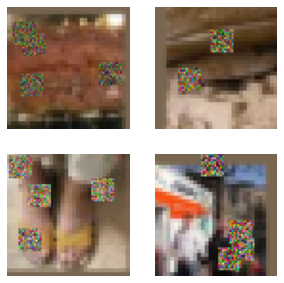

In [21]:
show_images(denorm(xb[:4]), imsize=2.5)

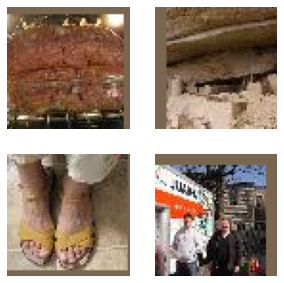

In [22]:
show_images(denorm(yb[:4]), imsize=2.5)

## Denoising autoencoder

In [23]:
def up_block(ni, nf, ks=3, act=act_gr, norm=None):
    return nn.Sequential(nn.UpsamplingNearest2d(scale_factor=2),
                         ResBlock(ni, nf, ks=ks, act=act, norm=norm))

In [24]:
def get_model(act=act_gr, nfs=(32,64,128,256,512,1024), norm=nn.BatchNorm2d, drop=0.1):
    layers = [ResBlock(3, nfs[0], ks=5, stride=1, act=act, norm=norm)]
    layers += [ResBlock(nfs[i], nfs[i+1], act=act, norm=norm, stride=2) for i in range(len(nfs)-1)]
    layers += [up_block(nfs[i], nfs[i-1], act=act, norm=norm) for i in range(len(nfs)-1,0,-1)]
    layers += [ResBlock(nfs[0], 3, act=nn.Identity, norm=norm)]
    return nn.Sequential(*layers).apply(iw)

In [25]:
iw = partial(init_weights, leaky=0.1)

In [26]:
metrics = MetricsCB()
cbs = [DeviceCB(), metrics, ProgressCB(plot=True), MixedPrecision()]
lr_cbs = [DeviceCB(), ProgressCB(), MixedPrecision()]
opt_func = partial(optim.AdamW, eps=1e-5)

/Users/lwei/Trees/fastai-course22p2/miniai/accel.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  def before_fit(self, learn): self.scaler = torch.cuda.amp.GradScaler()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/cuda/amp/grad_scaler.py:31: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  super().__init__(


<div><div><progress max="10" value="0"></progress> 0.00% [0/10 00:00&lt;?]</div><div></div><div><progress max="196" value="24"></progress> 12.24% [24/196 00:29&lt;03:30... 1.639]</div></div>

/Users/lwei/Trees/fastai-course22p2/miniai/accel.py:36: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  self.autocast = torch.autocast("cuda", dtype=torch.float16)


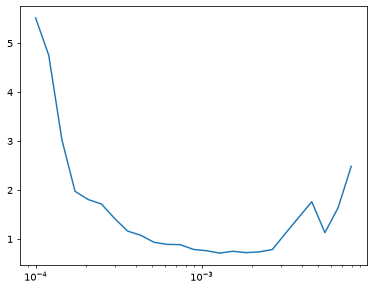

In [27]:
Learner(get_model().apply(iw), dls, F.mse_loss, cbs=lr_cbs, opt_func=opt_func).lr_find(start_lr=1e-4, gamma=1.2)

In [28]:
epochs = 5
lr = 1e-3
tmax = epochs * len(dls.train)
sched = partial(lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)
xtra = [BatchSchedCB(sched)]
learn = Learner(get_model().apply(iw), dls, F.mse_loss, lr=lr, cbs=cbs+xtra, opt_func=opt_func)

In [29]:
learn.summary()

<div><div><progress max="1" value="0"></progress> 0.00% [0/1 00:00&lt;?]</div><div></div><div><progress max="196" value="0"></progress> 0.00% [0/196 00:00&lt;?]</div></div>

Tot params: 29730854; MFLOPS: 1021.1


|Module|Input|Output|Num params|MFLOPS|
|--|--|--|--|--|
|ResBlock|(512, 3, 64, 64)|(512, 32, 64, 64)|28320|115.1|
|ResBlock|(512, 32, 64, 64)|(512, 64, 32, 32)|57792|58.7|
|ResBlock|(512, 64, 32, 32)|(512, 128, 16, 16)|230272|58.7|
|ResBlock|(512, 128, 16, 16)|(512, 256, 8, 8)|919296|58.7|
|ResBlock|(512, 256, 8, 8)|(512, 512, 4, 4)|3673600|58.7|
|ResBlock|(512, 512, 4, 4)|(512, 1024, 2, 2)|14687232|58.7|
|Sequential|(512, 1024, 2, 2)|(512, 512, 4, 4)|7605760|121.6|
|Sequential|(512, 512, 4, 4)|(512, 256, 8, 8)|1902336|121.6|
|Sequential|(512, 256, 8, 8)|(512, 128, 16, 16)|476032|121.6|
|Sequential|(512, 128, 16, 16)|(512, 64, 32, 32)|119232|121.6|
|Sequential|(512, 64, 32, 32)|(512, 32, 64, 64)|29920|121.6|
|ResBlock|(512, 32, 64, 64)|(512, 3, 64, 64)|1062|4.3|


loss,epoch,train
0.543,0,train
0.349,0,eval
0.302,1,train
0.262,1,eval
0.242,2,train
0.221,2,eval
0.219,3,train
0.211,3,eval
0.214,4,train
0.200,4,eval


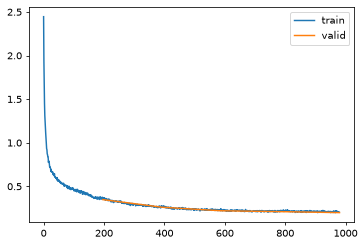

In [30]:
learn.fit(epochs)

loss,epoch,train
0.200,0,eval


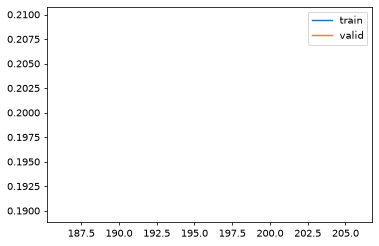

In [31]:
p,t,inp = learn.capture_preds(inps=True)

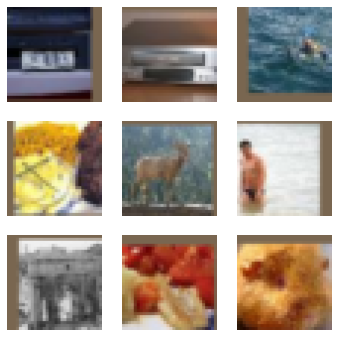

In [32]:
show_images(denorm(inp[:9]), imsize=2)

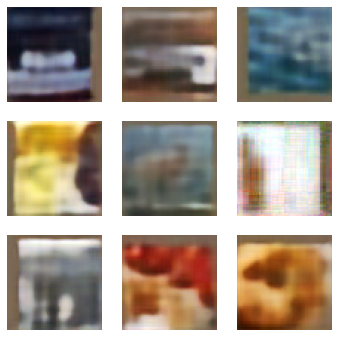

In [33]:
show_images(denorm(p[:9]), imsize=2)

## Unet

In [35]:
del(learn)
clean_mem()

Task was destroyed but it is pending!
task: <Task pending name='Task-224' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-225' coro=<Kernel.shell_main() running at /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/lwei/Trees/fastai-course22p2/miniai/init.py:58: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  gc.collect()
Task was destroyed but it is pending!
task: <Task pending name='Task-225' coro=<Kernel.shell_main() running at /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


Unet with skip connection via addition instead of channel concatenation

In [78]:
class TinyUnet(nn.Module):
    def __init__(self, act=act_gr, nfs=(32,64,128,256,512,1024), norm=nn.BatchNorm2d, ks=3):
        super().__init__()
        self.start = ResBlock(3, nfs[0], ks=ks, stride=1, act=act, norm=norm)
        self.dn = nn.ModuleList([ResBlock(nfs[i], nfs[i+1], act=act, norm=norm, stride=2)
                                 for i in range(len(nfs)-1)])
        self.up = nn.ModuleList([up_block(nfs[i], nfs[i-1], act=act, norm=norm)
                                 for i in range(len(nfs)-1,0,-1)])
        self.up += [ResBlock(nfs[0], 3, act=act, norm=norm)]
        self.end = ResBlock(3, 3, act=nn.Identity, norm=norm)

    def forward(self, x):
        layers = []
        layers.append(x)
        x = self.start(x)
        for l in self.dn:
            layers.append(x)
            x = l(x)
        n = len(layers)
        for i,l in enumerate(self.up):
            if i!=0: x += layers[n-i]
            x = l(x)
        return self.end(x+layers[0])

In [37]:
def zero_wgts(l):
    with torch.no_grad():
        l.weight.zero_()
        l.bias.zero_()

In [38]:
model = TinyUnet()

In [39]:
last_res = model.up[-1]
zero_wgts(last_res.convs[-1][-1])
zero_wgts(last_res.idconv[0])
zero_wgts(model.end.convs[-1][-1])

<div><div><progress max="10" value="0"></progress> 0.00% [0/10 00:00&lt;?]</div><div></div><div><progress max="196" value="34"></progress> 17.35% [34/196 00:41&lt;03:17... 0.500]</div></div>

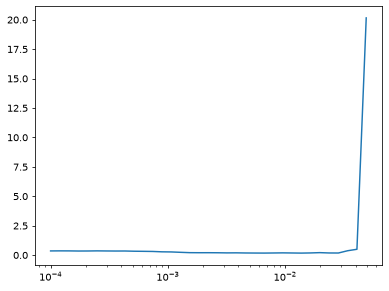

In [40]:
Learner(model, dls, F.mse_loss, cbs=lr_cbs, opt_func=opt_func).lr_find(start_lr=1e-4, gamma=1.2)

In [41]:
model = TinyUnet()

In [42]:
last_res = model.up[-1]
zero_wgts(last_res.convs[-1][-1])
zero_wgts(last_res.idconv[0])
zero_wgts(model.end.convs[-1][-1])

In [43]:
epochs = 20
lr = 1e-2
tmax = epochs * len(dls.train)
sched = partial(lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)
xtra = [BatchSchedCB(sched)]
learn = Learner(model, dls, F.mse_loss, lr=lr, cbs=cbs+xtra, opt_func=opt_func)

loss,epoch,train
0.161,0,train
0.081,0,eval
0.100,1,train
0.076,1,eval
0.090,2,train
0.073,2,eval
0.086,3,train
0.072,3,eval
0.084,4,train
0.071,4,eval


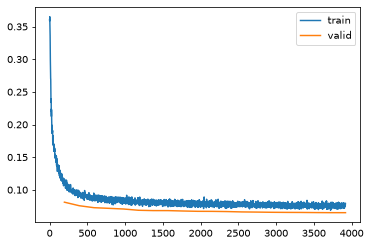

In [44]:
learn.fit(epochs)

loss,epoch,train
0.065,0,eval


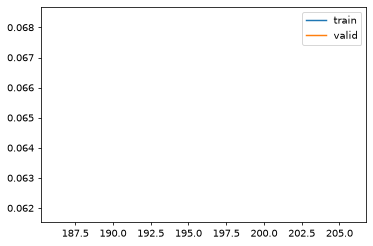

In [45]:
p,t,inp = learn.capture_preds(inps=True)

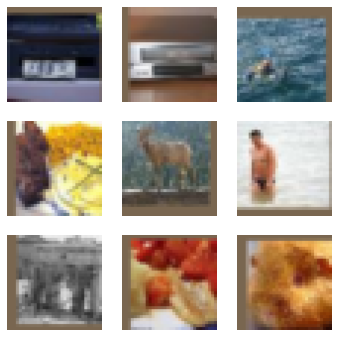

In [46]:
show_images(denorm(inp[:9]), imsize=2)

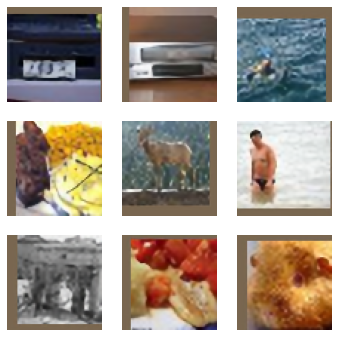

In [47]:
show_images(denorm(p[:9]), imsize=2)

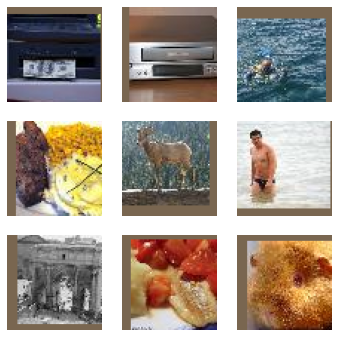

In [48]:
show_images(denorm(t[:9]), imsize=2)

## Perceptual loss

In [49]:
# del(learn)
# clean_mem()

In [51]:
cmodel = torch.load('models/inettiny-custom-25', weights_only=False, map_location=device).to(device)

In [55]:
xb,yb = next(iter(dls.valid))
if device == torch.device('cuda'):
    with torch.autocast('cuda'),torch.no_grad(): preds = to_cpu(cmodel(yb.to(device).half()))
else:
    with torch.no_grad(): preds = to_cpu(cmodel(yb.to(device)))
preds.shape

torch.Size([1024, 200])

In [56]:
id2str = (path/'wnids.txt').read_text().splitlines()
all_synsets = [o.split('\t') for o in (path/'words.txt').read_text().splitlines()]
synsets = {k:v.split(',', maxsplit=1)[0] for k,v in all_synsets if k in id2str}

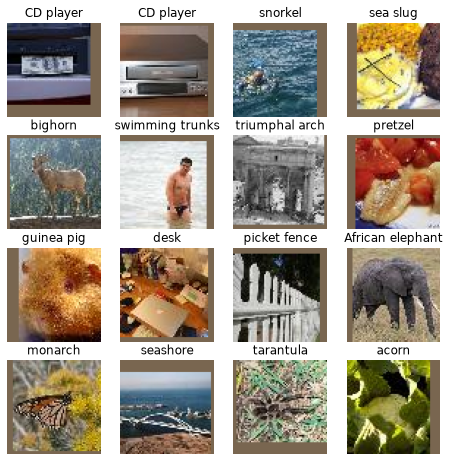

In [57]:
titles = [synsets[id2str[o]] for o in preds.argmax(dim=1)]
show_images(denorm(yb[:16]), imsize=2, titles=titles[:16])

In [58]:
for i in range(4,len(cmodel)): del(cmodel[4])

In [ ]:
#learn.model = torch.load('models/superres-cross.pkl')

In [59]:
with torch.autocast('cuda'),torch.no_grad():
    feat = to_cpu(cmodel(yb.to(device))).float()
    t = to_cpu(learn.model(yb.to(device))).float()
    pred_feat = to_cpu(cmodel(t.to(device))).float()

feat.shape

/var/folders/0r/ltkzn7w9481djppb2rfcnhvc0000gp/T/ipykernel_18900/1122936114.py:1: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.autocast('cuda'),torch.no_grad():


torch.Size([1024, 256, 8, 8])

In [61]:
def comb_loss(inp, tgt):
    with torch.autocast('cuda'):
        with torch.no_grad(): tgt_feat = cmodel(tgt).float()
        inp_feat = cmodel(inp).float()
    feat_loss = F.mse_loss(inp_feat, tgt_feat)
    return F.mse_loss(inp,tgt) + feat_loss/10

In [80]:
def get_unet(ks=3):
    model = TinyUnet(ks=ks)
    last_res = model.up[-1]
    zero_wgts(last_res.convs[-1][-1])
    zero_wgts(last_res.idconv[0])
    zero_wgts(model.end.convs[-1][-1])
    return model

<div><div><progress max="10" value="0"></progress> 0.00% [0/10 00:00&lt;?]</div><div></div><div><progress max="196" value="33"></progress> 16.84% [33/196 01:35&lt;07:52... 0.390]</div></div>

/var/folders/0r/ltkzn7w9481djppb2rfcnhvc0000gp/T/ipykernel_18900/58093646.py:2: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.autocast('cuda'):


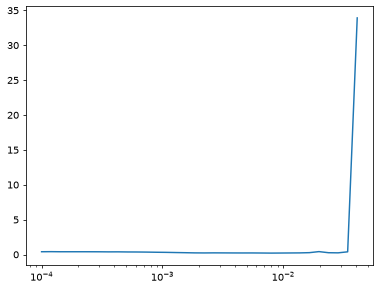

In [63]:
Learner(get_unet(), dls, comb_loss, cbs=lr_cbs, opt_func=opt_func).lr_find(start_lr=1e-4, gamma=1.2)

In [64]:
epochs = 20
lr = 1e-2
tmax = epochs * len(dls.train)
sched = partial(lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)
xtra = [BatchSchedCB(sched)]
learn = Learner(get_unet(), dls, comb_loss, lr=lr, cbs=cbs+xtra, opt_func=opt_func)

loss,epoch,train
0.192,0,train
0.106,0,eval
0.129,1,train
0.099,1,eval
0.117,2,train
0.096,2,eval
0.112,3,train
0.095,3,eval
0.109,4,train
0.092,4,eval


/var/folders/0r/ltkzn7w9481djppb2rfcnhvc0000gp/T/ipykernel_18900/58093646.py:2: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.autocast('cuda'):


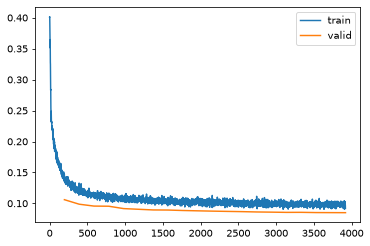

In [65]:
learn.fit(epochs)

loss,epoch,train
0.085,0,eval


/var/folders/0r/ltkzn7w9481djppb2rfcnhvc0000gp/T/ipykernel_18900/58093646.py:2: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.autocast('cuda'):


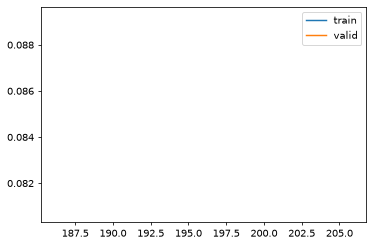

In [66]:
p,t,inp = learn.capture_preds(inps=True)

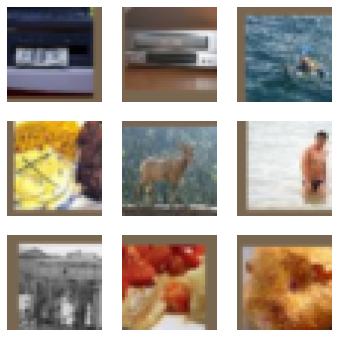

In [67]:
show_images(denorm(inp[:9]), imsize=2)

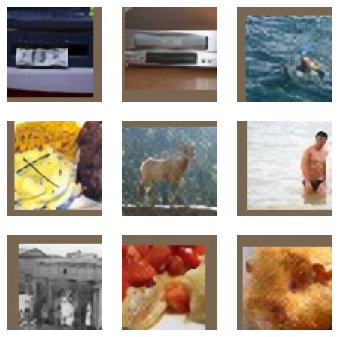

In [68]:
show_images(denorm(p[:9]), imsize=2)

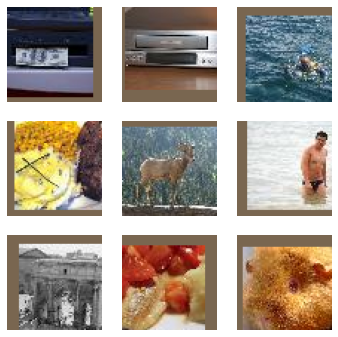

In [69]:
show_images(denorm(t[:9]), imsize=2)

## Perceptual loss

In [81]:
model = get_unet(ks=5)

In [75]:
pmodel = torch.load('models/inettiny-custom-25', weights_only = False, map_location=device)

In [84]:
model.start.load_state_dict(pmodel[0].state_dict())
for i in range(5): model.dn[i].load_state_dict(pmodel[i+1][0].state_dict())

In [85]:
for o in model.dn.parameters(): o.requires_grad_(False)

In [86]:
epochs = 1
lr = 3e-3
tmax = epochs * len(dls.train)
sched = partial(lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)
xtra = [BatchSchedCB(sched)]
learn = Learner(model, dls, comb_loss, lr=lr, cbs=cbs+xtra, opt_func=opt_func)

loss,epoch,train
0.178,0,train
0.106,0,eval


/var/folders/0r/ltkzn7w9481djppb2rfcnhvc0000gp/T/ipykernel_18900/58093646.py:2: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.autocast('cuda'):


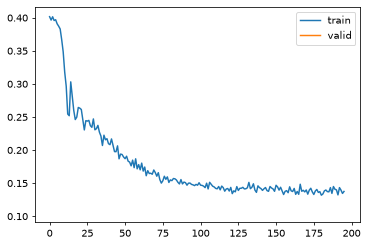

In [87]:
learn.fit(epochs)

In [88]:
for o in model.dn.parameters(): o.requires_grad_(True)

In [89]:
epochs = 20
lr = 3e-3
tmax = epochs * len(dls.train)
sched = partial(lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)
xtra = [BatchSchedCB(sched)]
learn = Learner(model, dls, comb_loss, lr=lr, cbs=cbs+xtra, opt_func=opt_func)

loss,epoch,train
0.135,0,train
0.104,0,eval
0.129,1,train
0.102,1,eval
0.123,2,train
0.099,2,eval
0.120,3,train
0.098,3,eval
0.117,4,train
0.097,4,eval


/var/folders/0r/ltkzn7w9481djppb2rfcnhvc0000gp/T/ipykernel_18900/58093646.py:2: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.autocast('cuda'):


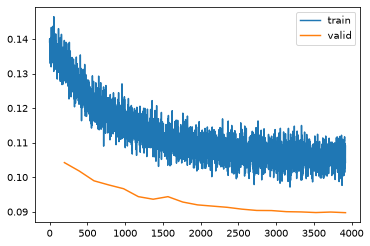

In [90]:
learn.fit(epochs)

In [91]:
torch.save(learn.model, 'models/superres-pcp.pkl')
# learn.model = torch.load('models/superres-pcp.pkl').to(device)

loss,epoch,train
0.090,0,eval


/var/folders/0r/ltkzn7w9481djppb2rfcnhvc0000gp/T/ipykernel_18900/58093646.py:2: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.autocast('cuda'):


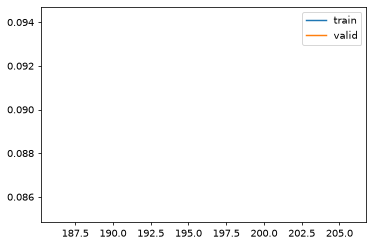

In [92]:
p,t,inp = learn.capture_preds(inps=True)

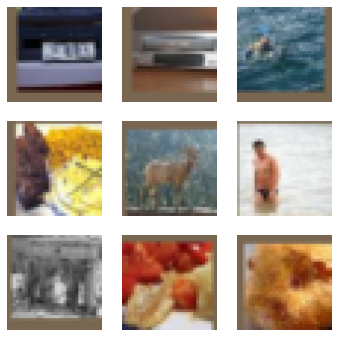

In [93]:
show_images(denorm(inp[:9]), imsize=2)

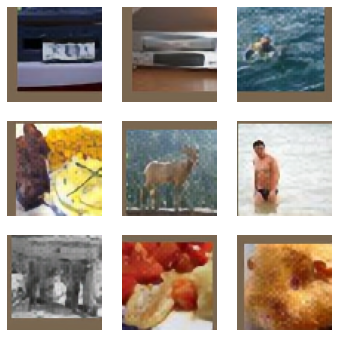

In [94]:
show_images(denorm(p[:9]), imsize=2)

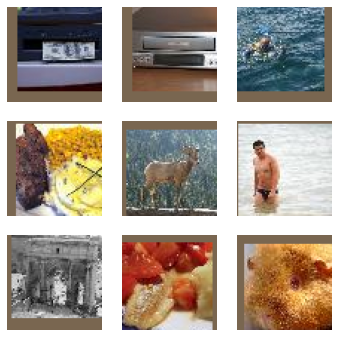

In [95]:
show_images(denorm(t[:9]), imsize=2)

In [96]:
torch.save(learn.model, 'models/superres-pcp.pkl')
# learn.model = torch.load('models/superres-pcp.pkl').to(device)

## Cross-convs

In [97]:
def cross_conv(nf, act, norm):
    return nn.Sequential(
        ResBlock(nf, nf, act=act, norm=norm),
        nn.Conv2d(nf, nf, 3, padding=1)
    )

In [98]:
class TinyUnet(TinyUnet):
    def __init__(self, act=act_gr, nfs=(32,64,128,256,512,1024), norm=nn.BatchNorm2d, ks=3):
        super().__init__(act=act, nfs=nfs, norm=norm, ks=ks)
        self.xs = nn.ModuleList([cross_conv(nfs[i], act, norm)
                                 for i in range(len(nfs)-1,0,-1)])
        self.xs += [cross_conv(nfs[0], act, norm)]

    def forward(self, x):
        layers = []
        layers.append(x)
        x = self.start(x)
        for l in self.dn:
            layers.append(x)
            x = l(x)
        n = len(layers)
        for i,l in enumerate(self.up):
            if i!=0: x += self.xs[i](layers[n-i])
            x = l(x)
        return self.end(x+layers[0])

In [100]:
pmodel = torch.load('models/inettiny-custom-25', weights_only = False, map_location=device)

In [101]:
model = get_unet(ks=5)

In [102]:
model.start.load_state_dict(pmodel[0].state_dict())
for i in range(5): model.dn[i].load_state_dict(pmodel[i+1][0].state_dict())
for o in model.dn.parameters(): o.requires_grad_(False)

In [103]:
epochs = 1
lr = 3e-3
tmax = epochs * len(dls.train)
sched = partial(lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)
xtra = [BatchSchedCB(sched)]
learn = Learner(model, dls, comb_loss, lr=lr, cbs=cbs+xtra, opt_func=opt_func)

loss,epoch,train
0.169,0,train
0.102,0,eval


/var/folders/0r/ltkzn7w9481djppb2rfcnhvc0000gp/T/ipykernel_18900/58093646.py:2: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.autocast('cuda'):


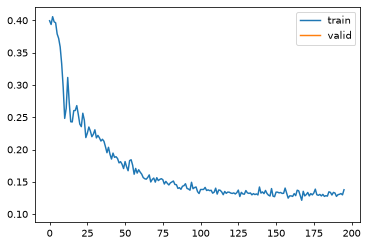

In [104]:
learn.fit(epochs)

In [105]:
for o in model.dn.parameters(): o.requires_grad_(True)

In [106]:
epochs = 20
lr = 1e-2
tmax = epochs * len(dls.train)
sched = partial(lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)
xtra = [BatchSchedCB(sched)]
learn = Learner(model, dls, comb_loss, lr=lr, cbs=cbs+xtra, opt_func=opt_func)

In [ ]:
learn.fit(epochs)

<div><div><progress max="20" value="0"></progress> 0.00% [0/20 00:00&lt;?]</div><div></div><div><progress max="196" value="51"></progress> 26.02% [51/196 36:54&lt;1:44:56... 0.127]</div></div>

/var/folders/0r/ltkzn7w9481djppb2rfcnhvc0000gp/T/ipykernel_18900/58093646.py:2: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.autocast('cuda'):


In [ ]:
p,t,inp = learn.capture_preds(inps=True)

loss,epoch,train
0.189,0,eval


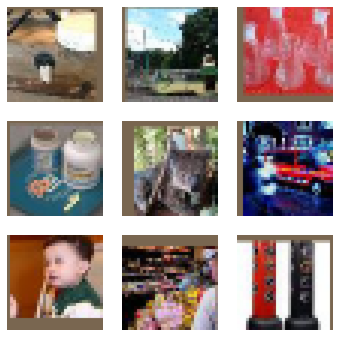

In [ ]:
show_images(denorm(inp[:9]), imsize=2)

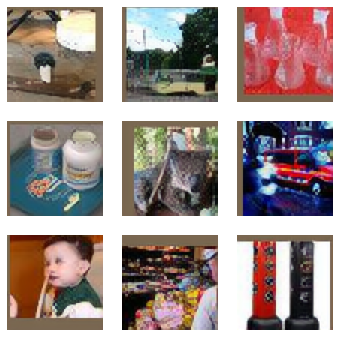

In [ ]:
show_images(denorm(p[:9]), imsize=2)

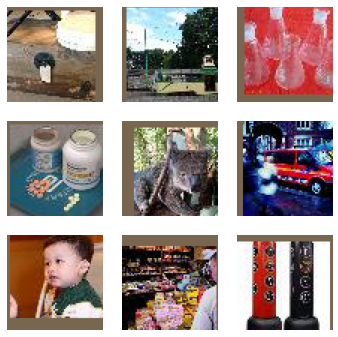

In [ ]:
show_images(denorm(t[:9]), imsize=2)

In [ ]:
torch.save(learn.model, 'models/superres-cross.pkl')
# learn.model = torch.load('models/superres-pcp.pkl').to(device)